# 03. Base Forecasting Models & Multimodal Feature Encoders

**DRL-Enhanced Multimodal Solar PV Forecasting Framework (SKIPP'D Dataset)**

### Objectives of this Notebook:

1. **Astronomical Solar Geometry & Clear-Sky Physics:** Compute solar zenith angle ($\theta_z$), azimuth ($\gamma_s$), Haurwitz clear-sky global horizontal irradiance ($\text{GHI}_{\text{clear}}$), clear-sky PV capacity ($P_{\text{clear}}$), clear-sky index ($k_t$), and 1-minute ramp volatility rate ($R_t$).
2. **Multimodal PyTorch Dataset Pipeline:** Build memory-mapped, low-RAM PyTorch `DataLoader` streams that simultaneously ingest historical PV power sequences, defisheyed sky images ($64\times 64\times 3$), and physical solar parameters.
3. **Implement 5 Base Forecasting Models:**
   - **Model 1: LSTM Forecaster** (Recurrent time-series sequence model)
   - **Model 2: Temporal Transformer Forecaster** (Multi-head self-attention sequence model)
   - **Model 3: CNN-LSTM Hybrid (SUNSET)** (Stanford University Neural Network for Solar Energy Tracking - Multimodal CV + Time-Series + Geometry fusion)
   - **Model 4: Temporal ConvNet (TCN)** (Dilated causal 1D convolutions with residual blocks)
   - **Model 5: Multi-Model Ensemble** (Optimized variance-weighted blending)
4. **Benchmarking & Physics-Aware Evaluation:** Evaluate MAE, RMSE, nMAE, nRMSE, Forecast Skill Score ($SS_{\text{persistence}}$), and Ramp-Rate error across **Sunny**, **Partly Cloudy**, and **Overcast** sky conditions.
5. **State Representation Bridge for DRL:** Extract and serialize the multimodal latent embeddings ($F_t$) and base model prediction vectors ($\hat{P}_t$) to `data/base_models_features_and_predictions.pt` and Google Drive for direct consumption by the **DRL Adaptive Controller** in `04-drl-agent.ipynb`.


## 1. Setup, Hardware Configuration & Dependencies

We configure PyTorch with automatic CUDA acceleration, mixed-precision training (`torch.cuda.amp`), and deterministic random seeds for full experimental reproducibility.


In [1]:
import os
import sys
import time
import math
import random
import shutil
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Check for pvlib for high-precision solar geometry
try:
    import pvlib

    HAS_PVLIB = True
except ImportError:
    HAS_PVLIB = False
    print("Note: pvlib not installed. Pure NumPy astronomical algorithms will be used.")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Visual styling
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["font.size"] = 10
plt.rcParams["figure.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12

Note: pvlib not installed. Pure NumPy astronomical algorithms will be used.
Using compute device: cuda
GPU: Tesla T4


## 2. Data Ingestion & Memory-Mapped Array Loading

We locate the SKIPP'D HDF5 dataset or pre-extracted `.npy` arrays across Colab local storage, Google Drive, or local workspaces. We use **NumPy memory-mapping** (`mmap_mode='r'`) so that the 4.0 GB image array resides on disk and is paged into memory on-demand per batch, maintaining a negligible RAM footprint.


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
# Search candidate paths for dataset files
possible_hdf5_paths = [
    "/content/data/2017_2019_images_pv_defisheye.hdf5",
    "/content/drive/MyDrive/solar_data/2017_2019_images_pv_defisheye.hdf5",
]

possible_extracted_dirs = ["/content/data/extracted/"]

hdf5_path = next((p for p in possible_hdf5_paths if os.path.exists(p)), None)
data_dir = next((d for d in possible_extracted_dirs if os.path.exists(d)), "./")

print(f"Identified data directory: {data_dir}")
if hdf5_path:
    print(f"Found direct HDF5 dataset: {hdf5_path}")
    f_h5 = h5py.File(hdf5_path, "r")
    trainval_images = f_h5["trainval"]["images_log"]
    trainval_pv = np.array(f_h5["trainval"]["pv_log"], dtype=np.float32)
    test_images = f_h5["test"]["images_log"]
    test_pv = np.array(f_h5["test"]["pv_log"], dtype=np.float32)
else:
    print("Loading via memory-mapped .npy files...")
    tv_img_p = os.path.join(data_dir, "trainval_images_defisheye.npy")
    if not os.path.exists(tv_img_p):
        tv_img_p = os.path.join(data_dir, "trainval_images_log.npy")
    trainval_images = np.load(tv_img_p, mmap_mode="r")
    trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy")).astype(
        np.float32
    )

    te_img_p = os.path.join(data_dir, "test_images_defisheye.npy")
    if not os.path.exists(te_img_p):
        te_img_p = os.path.join(data_dir, "test_images_log.npy")
    test_images = np.load(te_img_p, mmap_mode="r")
    test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy")).astype(np.float32)


# Load timestamps
def find_file(fname):
    candidates = [
        f"/content/data/{fname}",
        f"/content/data/extracted/{fname}",
        f"/content/drive/MyDrive/solar_data/{fname}",
        f"./data/{fname}",
        f"./{fname}",
    ]
    return next((c for c in candidates if os.path.exists(c)), None)


t_tv_path = find_file("times_trainval.npy")
t_te_path = find_file("times_test.npy")

trainval_times = (
    pd.to_datetime(np.load(t_tv_path, allow_pickle=True)) if t_tv_path else None
)
test_times = (
    pd.to_datetime(np.load(t_te_path, allow_pickle=True)) if t_te_path else None
)

print("=" * 70)
print(f"Train/Val Images: {trainval_images.shape} | PV Array: {trainval_pv.shape}")
print(f"Test Images:     {test_images.shape} | PV Array: {test_pv.shape}")
if trainval_times is not None:
    print(f"Train/Val Dates:  {trainval_times[0]} to {trainval_times[-1]}")
if test_times is not None:
    print(f"Test Dates:       {test_times[0]} to {test_times[-1]}")
print("=" * 70)

Identified data directory: /content/data/extracted/
Loading via memory-mapped .npy files...
Train/Val Images: (349372, 64, 64, 3) | PV Array: (349372,)
Test Images:     (14003, 64, 64, 3) | PV Array: (14003,)
Train/Val Dates:  2017-03-09 06:47:00 to 2019-10-26 17:59:20
Test Dates:       2017-09-15 07:11:00 to 2019-10-19 18:15:30


## 3. Solar Geometry, Clear-Sky Physics & Optical Feature Engineering

Following the physics-informed pipeline in `02-eda.ipynb`, we compute:

1. **Solar Zenith Angle ($\theta_z$) & Azimuth Angle ($\gamma_s$)** using Stanford's geographical coordinates ($37.4275^\circ\text{N}, -122.1700^\circ\text{W}$).
2. **Continuous Trigonometric Encodings:** $[\sin(\theta_z), \cos(\theta_z), \sin(\gamma_s), \cos(\gamma_s)]$ to eliminate directional angle wrap-around discontinuities.
3. **Clear-Sky Global Horizontal Irradiance ($\text{GHI}_{\text{clear}}$):** Modeled via the Haurwitz clear-sky solar radiation model.
4. **Theoretical Clear-Sky PV Power ($P_{\text{clear}}$):** Scaled to the Stanford 30-kW rooftop array capacity.
5. **Clear-Sky Index ($k_t$):** Normalizes generation against theoretical maximum: $k_t = P_t / P_{\text{clear}, t}$.
6. **1-Minute Ramp Volatility Rate ($R_t$):** Quantifies cloud-induced ramp events: $R_t = |P_t - P_{t-1}|$.
7. **Sky Condition Classification:** Segmenting observations into **Sunny (Clear Sky)**, **Partly Cloudy (High Ramp Volatility)**, and **Overcast / Cloudy**.


In [8]:
STANFORD_LAT = 37.4275
STANFORD_LON = -122.1700
STANFORD_TZ = "America/Los_Angeles"
PV_SYSTEM_CAPACITY_KW = (
    29.58  # Maximum empirical capacity of the Stanford rooftop array
)


def compute_solar_features(pv_array, timestamps=None):
    """
    Computes astronomical solar position, clear-sky irradiance, clear-sky capacity,
    clear-sky index (k_t), trigonometric angular encodings, and 1-minute ramp rates.
    """
    N = len(pv_array)
    df = pd.DataFrame({"pv": pv_array.astype(np.float32)})

    if timestamps is not None and len(timestamps) == N:
        df["timestamp"] = pd.to_datetime(timestamps)
        times_dt = pd.DatetimeIndex(df["timestamp"])

        if HAS_PVLIB:
            if times_dt.tz is None:
                times_localized = times_dt.tz_localize(STANFORD_TZ)
            else:
                times_localized = times_dt

            solpos = pvlib.solarposition.get_solarposition(
                times_localized, STANFORD_LAT, STANFORD_LON
            )
            df["zenith"] = solpos["zenith"].values.astype(np.float32)
            df["azimuth"] = solpos["azimuth"].values.astype(np.float32)

            cs = pvlib.clearsky.haurwitz(solpos["apparent_zenith"])
            ghi_clear = cs["ghi"].values.astype(np.float32)
            df["ghi_clear"] = ghi_clear

            p_clear = np.minimum(
                PV_SYSTEM_CAPACITY_KW,
                (ghi_clear / 1000.0) * PV_SYSTEM_CAPACITY_KW * 1.05,
            )
            df["p_clear"] = np.maximum(0.2, p_clear).astype(np.float32)
        else:
            # Astronomical NumPy equations fallback
            doy = times_dt.dayofyear.values
            decl = 23.45 * np.sin(np.deg2rad(360.0 / 365.0 * (doy - 81)))
            b = np.deg2rad(360.0 / 364.0 * (doy - 81))
            eot = 9.87 * np.sin(2 * b) - 7.53 * np.cos(b) - 1.5 * np.sin(b)
            hours = times_dt.hour.values + times_dt.minute.values / 60.0
            lstm = 15.0 * (-8.0)  # PST = UTC-8
            tc = 4.0 * (STANFORD_LON - lstm) + eot
            lst = hours + tc / 60.0
            hra = 15.0 * (lst - 12.0)

            lat_rad = np.deg2rad(STANFORD_LAT)
            decl_rad = np.deg2rad(decl)
            hra_rad = np.deg2rad(hra)
            cos_zenith = np.sin(lat_rad) * np.sin(decl_rad) + np.cos(lat_rad) * np.cos(
                decl_rad
            ) * np.cos(hra_rad)
            cos_zenith = np.clip(cos_zenith, 0.0, 1.0)
            df["zenith"] = np.rad2deg(np.arccos(cos_zenith)).astype(np.float32)
            df["azimuth"] = 180.0
            df["ghi_clear"] = (1098.0 * (cos_zenith**1.1)).astype(np.float32)
            df["p_clear"] = np.maximum(
                0.2, PV_SYSTEM_CAPACITY_KW * (cos_zenith**1.1)
            ).astype(np.float32)
    else:
        df["zenith"] = 45.0
        df["azimuth"] = 180.0
        df["ghi_clear"] = 800.0
        df["p_clear"] = 25.0

    # Clear-Sky Index k_t
    df["k_t"] = np.clip(df["pv"] / df["p_clear"], 0.0, 1.5).astype(np.float32)

    # 1-minute ramp rate (|ΔP_t| in kW/min)
    df["ramp_rate"] = np.abs(df["pv"].diff().fillna(0.0)).astype(np.float32)

    # Continuous trigonometric features
    zen_rad = np.deg2rad(df["zenith"].values)
    az_rad = np.deg2rad(df["azimuth"].values)
    df["sin_zenith"] = np.sin(zen_rad).astype(np.float32)
    df["cos_zenith"] = np.cos(zen_rad).astype(np.float32)
    df["sin_azimuth"] = np.sin(az_rad).astype(np.float32)
    df["cos_azimuth"] = np.cos(az_rad).astype(np.float32)

    # Sky condition classification
    # 0 = Sunny / Clear Sky, 1 = Partly Cloudy / Volatile, 2 = Overcast / Diffuse
    sky_condition = np.full(N, 1, dtype=np.int64)
    sunny_mask = (df["k_t"] >= 0.85) & (df["ramp_rate"] <= 1.0)
    overcast_mask = df["k_t"] < 0.40
    sky_condition[sunny_mask] = 0
    sky_condition[overcast_mask] = 2
    df["sky_condition"] = sky_condition

    return df


print("Computing solar geometry and physics features for Train/Val...")
df_tv = compute_solar_features(trainval_pv, trainval_times)
print("Computing solar geometry and physics features for Test...")
df_te = compute_solar_features(test_pv, test_times)
print(f"Solar physics features computed. Feature columns: {list(df_tv.columns)}")

Computing solar geometry and physics features for Train/Val...
Computing solar geometry and physics features for Test...
Solar physics features computed. Feature columns: ['pv', 'timestamp', 'zenith', 'azimuth', 'ghi_clear', 'p_clear', 'k_t', 'ramp_rate', 'sin_zenith', 'cos_zenith', 'sin_azimuth', 'cos_azimuth', 'sky_condition']


## 4. Multimodal PyTorch Dataset & DataLoader Pipeline

### Sequence & Horizon Definitions

- **Lookback Window ($T_{\text{in}}$):** 15 timesteps (15 minutes of historical PV generation sequence: $[P_{t-14}, \dots, P_t]$ and solar physical variables).
- **Forecast Horizon ($H$):** 15 timesteps ahead ($t+15$, i.e. 15-minute ahead nowcast $P_{t+15}$), matching standard solar forecasting benchmarks.
- **Input Image ($I_t$):** The current $64\times 64\times 3$ defisheyed RGB sky camera image at time $t$.
- **Nighttime Filtering:** We filter out timesteps where solar zenith angle $\theta_z > 85^\circ$ or $P_{\text{clear}} < 0.2\,\text{kW}$ to ensure models are trained and evaluated strictly on daylight solar generation hours.


In [9]:
LOOKBACK_WINDOW = 15  # T_in = 15 minutes
FORECAST_HORIZON = 15  # H = 15 minutes ahead


class SKIPPDSolarDataset(Dataset):
    """
    PyTorch Dataset for Multimodal Solar PV Nowcasting.
    Provides aligned pairs of:
      1. Time Series Sequence: (T_in, num_ts_features)
      2. Sky Camera Image:     (3, 64, 64) normalized in [0, 1]
      3. Solar Geometry Vector:(num_geo_features,)
      4. Target PV Power:      (1,) in kW (at t + H)
      5. Metadata dict:        (p_clear, k_t, ramp_rate, sky_condition, timestamp_idx)
    """

    def __init__(
        self,
        images_array,
        df_features,
        valid_indices,
        lookback=15,
        horizon=15,
        transform=None,
    ):
        self.images = images_array
        self.df = df_features
        self.valid_indices = valid_indices
        self.lookback = lookback
        self.horizon = horizon
        self.transform = transform

        # Pre-extract numerical columns into contiguous float32 numpy arrays for fast indexing
        self.pv_values = self.df["pv"].values.astype(np.float32)
        self.p_clear_values = self.df["p_clear"].values.astype(np.float32)
        self.kt_values = self.df["k_t"].values.astype(np.float32)
        self.ramp_values = self.df["ramp_rate"].values.astype(np.float32)
        self.sky_cond_values = self.df["sky_condition"].values.astype(np.int64)

        # Time-series features: [pv_norm, sin_zen, cos_zen, sin_az, cos_az, k_t]
        self.ts_matrix = np.column_stack(
            [
                self.pv_values / PV_SYSTEM_CAPACITY_KW,
                self.df["sin_zenith"].values,
                self.df["cos_zenith"].values,
                self.df["sin_azimuth"].values,
                self.df["cos_azimuth"].values,
                self.kt_values,
            ]
        ).astype(np.float32)

        # Instantaneous geometry features at time t: [sin_zen, cos_zen, sin_az, cos_az, ghi_clear_norm, p_clear_norm, k_t]
        self.geo_matrix = np.column_stack(
            [
                self.df["sin_zenith"].values,
                self.df["cos_zenith"].values,
                self.df["sin_azimuth"].values,
                self.df["cos_azimuth"].values,
                self.df["ghi_clear"].values / 1000.0,
                self.p_clear_values / PV_SYSTEM_CAPACITY_KW,
                self.kt_values,
            ]
        ).astype(np.float32)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]

        # 1. Historical Time Series Sequence: [t - lookback + 1 : t + 1]
        ts_seq = self.ts_matrix[
            t - self.lookback + 1 : t + 1
        ]  # Shape: (lookback, num_features)

        # 2. Sky Camera Image at time t: (64, 64, 3) uint8 -> (3, 64, 64) float32 in [0, 1]
        raw_img = self.images[t]
        img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
        if self.transform:
            img_tensor = self.transform(img_tensor)

        # 3. Solar Geometry Vector at time t
        geo_vec = self.geo_matrix[t]

        # 4. Target PV Generation at forecast horizon (t + H)
        target_pv = self.pv_values[t + self.horizon]

        # 5. Metadata for downstream evaluation and DRL state composition
        meta = {
            "idx": t,
            "p_clear_t": self.p_clear_values[t],
            "p_clear_target": self.p_clear_values[t + self.horizon],
            "k_t": self.kt_values[t],
            "ramp_rate": self.ramp_values[t],
            "sky_condition": self.sky_cond_values[t],
        }

        return {
            "ts_seq": torch.from_numpy(ts_seq),
            "image": img_tensor,
            "geo": torch.from_numpy(geo_vec),
            "target": torch.tensor([target_pv], dtype=torch.float32),
            "p_clear_target": torch.tensor(
                [meta["p_clear_target"]], dtype=torch.float32
            ),
            "sky_condition": torch.tensor(meta["sky_condition"], dtype=torch.long),
            "ramp_rate": torch.tensor([meta["ramp_rate"]], dtype=torch.float32),
            "k_t": torch.tensor([meta["k_t"]], dtype=torch.float32),
        }

### Temporal Chronological Split & Index Filtering

To prevent temporal lookahead bias, we split the 2017-2019 dataset chronologically:

- **Training Set:** First 80% of `trainval` daylight sequence.
- **Validation Set:** Remaining 20% of `trainval` daylight sequence.
- **Test Set:** Official held-out test split.


In [10]:
def get_valid_daylight_indices(df, lookback=15, horizon=15):
    """
    Identifies valid timesteps where history [t - lookback + 1, t] and target [t + horizon]
    are daylight hours (zenith < 85 deg, p_clear >= 0.2 kW).
    """
    N = len(df)
    is_daylight = (df["zenith"].values < 85.0) & (df["p_clear"].values >= 0.2)

    valid_indices = []
    for t in range(lookback - 1, N - horizon):
        # Must be daylight at time t and target horizon t + horizon
        if is_daylight[t] and is_daylight[t + horizon]:
            valid_indices.append(t)

    return np.array(valid_indices, dtype=np.int64)


valid_tv_indices = get_valid_daylight_indices(df_tv, LOOKBACK_WINDOW, FORECAST_HORIZON)
valid_te_indices = get_valid_daylight_indices(df_te, LOOKBACK_WINDOW, FORECAST_HORIZON)

# Chronological 80/20 train/validation split
n_tv = len(valid_tv_indices)
split_idx = int(0.80 * n_tv)
train_indices = valid_tv_indices[:split_idx]
val_indices = valid_tv_indices[split_idx:]
test_indices = valid_te_indices

print(f"Total Daylight Samples:")
print(f"  -> Training Samples:   {len(train_indices):,}")
print(f"  -> Validation Samples: {len(val_indices):,}")
print(f"  -> Test Samples:       {len(test_indices):,}")

# Instantiate Datasets
train_dataset = SKIPPDSolarDataset(
    trainval_images, df_tv, train_indices, LOOKBACK_WINDOW, FORECAST_HORIZON
)
val_dataset = SKIPPDSolarDataset(
    trainval_images, df_tv, val_indices, LOOKBACK_WINDOW, FORECAST_HORIZON
)
test_dataset = SKIPPDSolarDataset(
    test_images, df_te, test_indices, LOOKBACK_WINDOW, FORECAST_HORIZON
)

# Subsampling for rapid cloud experimentation if desired (default: use representative subset or full)
# You can adjust BATCH_SIZE and NUM_WORKERS to maximize GPU throughput
BATCH_SIZE = 128
NUM_WORKERS = 2 if os.name != "nt" else 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# Inspect a sample batch
sample_batch = next(iter(train_loader))
print("\nSample DataLoader Batch:")
print(
    f"  Time Series Tensor:  {sample_batch['ts_seq'].shape} (Batch, Lookback, Features)"
)
print(
    f"  Sky Image Tensor:    {sample_batch['image'].shape} (Batch, Channels, Height, Width)"
)
print(f"  Solar Geo Tensor:    {sample_batch['geo'].shape} (Batch, Geo_Features)")
print(f"  Target Output:       {sample_batch['target'].shape} (Batch, 1)")

Total Daylight Samples:
  -> Training Samples:   254,069
  -> Validation Samples: 63,518
  -> Test Samples:       12,657


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te


Sample DataLoader Batch:
  Time Series Tensor:  torch.Size([128, 15, 6]) (Batch, Lookback, Features)
  Sky Image Tensor:    torch.Size([128, 3, 64, 64]) (Batch, Channels, Height, Width)
  Solar Geo Tensor:    torch.Size([128, 7]) (Batch, Geo_Features)
  Target Output:       torch.Size([128, 1]) (Batch, 1)


## 5. Multimodal Feature Encoders & Base Forecasting Architectures

We implement the five base forecasting models specified in the architecture diagram. Each model exposes an `.encode_features()` method to extract the latent embedding vector $F_t$ alongside the base forecast $\hat{P}_t$, creating the foundation for the DRL state representation.


### 5.1 Model 1: LSTM Forecaster (Recurrent Baseline)

- Ingests historical PV power and solar position sequence.
- 2-layer stacked bidirectional LSTM with temporal pooling and MLP regressor head.


In [11]:
class LSTMForecaster(nn.Module):
    """
    Stacked Bidirectional LSTM Forecaster for PV generation time-series.
    """

    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        # Bidirectional produces 2 * hidden_dim
        self.fc_latent = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def encode_features(self, ts_seq):
        out, (hn, cn) = self.lstm(ts_seq)
        # Pool last timestep representations from both directions
        last_hidden = out[:, -1, :]
        latent = self.fc_latent(last_hidden)
        return latent

    def forward(self, ts_seq, images=None, geo=None):
        latent = self.encode_features(ts_seq)
        pred_norm = self.head(latent)
        pred_kw = pred_norm * PV_SYSTEM_CAPACITY_KW
        return pred_kw, latent


model_lstm = LSTMForecaster().to(device)
print(model_lstm)

LSTMForecaster(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc_latent): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 5.2 Model 2: Temporal Transformer Forecaster

- Positional Encoding + Multi-Head Self-Attention layers.
- Captures long-range temporal dependencies and cross-step irradiance correlations.


In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class TransformerForecaster(nn.Module):
    """
    Temporal Transformer with Multi-Head Self-Attention for solar time-series nowcasting.
    """

    def __init__(
        self,
        input_dim=6,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
    ):
        super(TransformerForecaster, self).__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=50)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.fc_latent = nn.Sequential(
            nn.Linear(d_model, 64), nn.LayerNorm(64), nn.GELU()
        )

        self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def encode_features(self, ts_seq):
        x = self.input_proj(ts_seq) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        trans_out = self.transformer_encoder(x)
        # Global average + last timestep representation
        pooled = trans_out[:, -1, :]
        latent = self.fc_latent(pooled)
        return latent

    def forward(self, ts_seq, images=None, geo=None):
        latent = self.encode_features(ts_seq)
        pred_norm = self.head(latent)
        pred_kw = pred_norm * PV_SYSTEM_CAPACITY_KW
        return pred_kw, latent


model_transformer = TransformerForecaster().to(device)
print(model_transformer)

TransformerForecaster(
  (input_proj): Linear(in_features=6, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_latent): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU

### 5.3 Model 3: CNN-LSTM Hybrid (SUNSET Multimodal Framework)

Implements the multimodal architecture:

- **Image Stream:** 2D Convolutional Backbone (Conv2D $\rightarrow$ BatchNorm $\rightarrow$ ReLU $\rightarrow$ MaxPool) extracting visual cloud patterns ($F_{\text{img}}$).
- **Time Series Stream:** LSTM encoding past PV dynamics ($F_{\text{time}}$).
- **Geometry Stream:** MLP encoding solar position & clear-sky physics ($F_{\text{geo}}$).
- **Cross-Modal Fusion:** Latent concatenation $F_t = [F_{\text{time}}; F_{\text{img}}; F_{\text{geo}}]$ passed into a dense fusion regression network.


In [13]:
class ImageEncoderCNN(nn.Module):
    """
    2D Convolutional Backbone for 64x64x3 Sky Camera Images.
    """

    def __init__(self, latent_dim=64):
        super(ImageEncoderCNN, self).__init__()
        self.conv_net = nn.Sequential(
            # Block 1: (3, 64, 64) -> (32, 32, 32)
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 2: (32, 32, 32) -> (64, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Block 3: (64, 16, 16) -> (128, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Global pooling: (128, 8, 8) -> (128, 1, 1)
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, latent_dim), nn.LayerNorm(latent_dim), nn.ReLU()
        )

    def forward(self, img):
        features = self.conv_net(img)
        features = features.view(features.size(0), -1)
        return self.fc(features)


class SUNSETMultimodalForecaster(nn.Module):
    """
    SUNSET (Stanford University Neural Network for Solar Energy Tracking)
    End-to-End Multimodal Architecture combining Sky Images + PV Time Series + Solar Geometry.
    """

    def __init__(
        self,
        ts_dim=6,
        geo_dim=7,
        img_latent=64,
        ts_latent=64,
        geo_latent=32,
        fusion_dim=128,
    ):
        super(SUNSETMultimodalForecaster, self).__init__()

        # 1. Image Encoder (CNN)
        self.image_encoder = ImageEncoderCNN(latent_dim=img_latent)

        # 2. Time Series Encoder (LSTM)
        self.ts_lstm = nn.LSTM(
            ts_dim, ts_latent, num_layers=2, batch_first=True, bidirectional=False
        )
        self.ts_fc = nn.Sequential(
            nn.Linear(ts_latent, ts_latent), nn.LayerNorm(ts_latent), nn.ReLU()
        )

        # 3. Geometry Encoder (MLP)
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_dim, geo_latent),
            nn.LayerNorm(geo_latent),
            nn.ReLU(),
            nn.Linear(geo_latent, geo_latent),
            nn.ReLU(),
        )

        # 4. Multimodal Fusion Network
        total_latent_dim = img_latent + ts_latent + geo_latent  # 64 + 64 + 32 = 160
        self.fusion = nn.Sequential(
            nn.Linear(total_latent_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fusion_dim, 64),
            nn.ReLU(),
        )

        # Output Regression Head
        self.head = nn.Linear(64, 1)

    def encode_features(self, ts_seq, images, geo):
        f_img = self.image_encoder(images)  # (B, 64)
        lstm_out, _ = self.ts_lstm(ts_seq)
        f_ts = self.ts_fc(lstm_out[:, -1, :])  # (B, 64)
        f_geo = self.geo_mlp(geo)  # (B, 32)

        # Concatenated Multimodal Feature Vector F_t
        f_concat = torch.cat([f_ts, f_img, f_geo], dim=-1)  # (B, 160)
        f_multimodal = self.fusion(f_concat)  # (B, 64)
        return f_multimodal

    def forward(self, ts_seq, images, geo):
        latent = self.encode_features(ts_seq, images, geo)
        pred_norm = self.head(latent)
        pred_kw = pred_norm * PV_SYSTEM_CAPACITY_KW
        return pred_kw, latent


model_sunset = SUNSETMultimodalForecaster().to(device)
print(model_sunset)

SUNSETMultimodalForecaster(
  (image_encoder): ImageEncoderCNN(
    (conv_net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): AdaptiveAvgPool2d(output_size=(1, 1))
   

### 5.4 Model 4: Temporal ConvNet (TCN)

- Dilated Causal 1D Convolutions with exponentially expanding receptive field ($d = 1, 2, 4, 8$).
- Residual connections and Weight Normalization for stable long-sequence modeling.


In [14]:
class ChausalConv1dBlock(nn.Module):
    def __init__(
        self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2
    ):
        super(ChausalConv1dBlock, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation,
        )
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation,
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.resample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else None
        )
        self.final_relu = nn.ReLU()

    def forward(self, x):
        # x: (B, C, L)
        res = x if self.resample is None else self.resample(x)

        out = self.conv1(x)
        out = out[:, :, : -self.padding] if self.padding > 0 else out  # Causal slice
        out = self.drop1(self.relu1(self.bn1(out)))

        out = self.conv2(out)
        out = out[:, :, : -self.padding] if self.padding > 0 else out
        out = self.drop2(self.relu2(self.bn2(out)))

        return self.final_relu(out + res)


class TCNForecaster(nn.Module):
    """
    Temporal Convolutional Network (TCN) with Dilated Causal Residual Blocks.
    """

    def __init__(
        self, input_dim=6, num_channels=[32, 64, 64], kernel_size=3, dropout=0.2
    ):
        super(TCNForecaster, self).__init__()
        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(num_channels):
            dilation = 2**i
            layers.append(
                ChausalConv1dBlock(
                    in_ch,
                    out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            in_ch = out_ch
        self.tcn = nn.Sequential(*layers)

        self.fc_latent = nn.Sequential(
            nn.Linear(num_channels[-1], 64), nn.LayerNorm(64), nn.ReLU()
        )
        self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    def encode_features(self, ts_seq):
        # Transpose from (B, L, C) -> (B, C, L)
        x = ts_seq.permute(0, 2, 1)
        out = self.tcn(x)
        last_timestep = out[:, :, -1]
        latent = self.fc_latent(last_timestep)
        return latent

    def forward(self, ts_seq, images=None, geo=None):
        latent = self.encode_features(ts_seq)
        pred_norm = self.head(latent)
        pred_kw = pred_norm * PV_SYSTEM_CAPACITY_KW
        return pred_kw, latent


model_tcn = TCNForecaster().to(device)
print(model_tcn)

TCNForecaster(
  (tcn): Sequential(
    (0): ChausalConv1dBlock(
      (conv1): Conv1d(6, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (resample): Conv1d(6, 32, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): ChausalConv1dBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
 

### 5.5 Model 5: Multi-Model Ensemble Forecaster

Combines the forecasts of the individual base models via optimal variance weighting:
$$\hat{P}_{\text{ensemble}, t} = \sum_{i=1}^{M} w_i \hat{P}_{i, t}, \quad \sum w_i = 1$$


In [15]:
class EnsembleForecaster(nn.Module):
    """
    Learnable / Variance-Weighted Blending Ensemble of Base Forecasting Models.
    """

    def __init__(self, num_models=4):
        super(EnsembleForecaster, self).__init__()
        # Softmax normalized model weights initialized uniformly
        self.raw_weights = nn.Parameter(torch.ones(num_models) / num_models)

    def forward(self, preds_list):
        # preds_list: tensor of shape (Batch, num_models)
        weights = F.softmax(self.raw_weights, dim=0)
        ensemble_pred = torch.matmul(preds_list, weights).unsqueeze(1)
        return ensemble_pred, weights

## 6. Training & Validation Engine

We implement a unified, modular training loop supporting:

- **Ramp-Aware Loss Function:** $L = \text{MSE} + \lambda_{\text{ramp}} |\Delta \hat{P} - \Delta P|$
- **AdamW Optimizer** with Cosine Annealing Learning Rate Decay.
- **Automatic Model Checkpointing & Early Stopping** on validation loss.


In [16]:
class SolarLoss(nn.Module):
    """
    Combined Huber / MSE Loss with physics-aware Ramp Volatility Penalty.
    """

    def __init__(self, ramp_weight=0.1):
        super(SolarLoss, self).__init__()
        self.mse = nn.SmoothL1Loss(
            beta=1.0
        )  # Huber loss is robust to outlier cloud spikes
        self.ramp_weight = ramp_weight

    def forward(self, y_pred, y_true, ramp_rate=None):
        base_loss = self.mse(y_pred, y_true)
        if self.ramp_weight > 0 and ramp_rate is not None:
            # Extra weight on rapid transition errors
            ramp_penalty = torch.mean(
                torch.abs(y_pred - y_true) * torch.clamp(ramp_rate / 2.0, 0.5, 2.0)
            )
            return base_loss + self.ramp_weight * ramp_penalty
        return base_loss


def train_single_model(
    model, train_loader, val_loader, model_name, epochs=15, lr=1e-3, is_multimodal=False
):
    print(f"\n>>> Training [{model_name}] for {epochs} Epochs on {device}...")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    criterion = SolarLoss(ramp_weight=0.05)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_rmse": []}
    best_val_loss = float("inf")
    best_weights_path = f"best_{model_name.lower().replace(' ', '_')}.pth"

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_accum = 0.0

        for batch in train_loader:
            ts_seq = batch["ts_seq"].to(device, non_blocking=True)
            images = (
                batch["image"].to(device, non_blocking=True) if is_multimodal else None
            )
            geo = batch["geo"].to(device, non_blocking=True) if is_multimodal else None
            target = batch["target"].to(device, non_blocking=True)
            ramp = batch["ramp_rate"].to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                if is_multimodal:
                    preds, _ = model(ts_seq, images, geo)
                else:
                    preds, _ = model(ts_seq)
                loss = criterion(preds, target, ramp)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss_accum += loss.item() * ts_seq.size(0)

        scheduler.step()
        train_loss = train_loss_accum / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss_accum = 0.0
        val_sq_errors = []
        val_abs_errors = []

        with torch.no_grad():
            for batch in val_loader:
                ts_seq = batch["ts_seq"].to(device, non_blocking=True)
                images = (
                    batch["image"].to(device, non_blocking=True)
                    if is_multimodal
                    else None
                )
                geo = (
                    batch["geo"].to(device, non_blocking=True)
                    if is_multimodal
                    else None
                )
                target = batch["target"].to(device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    if is_multimodal:
                        preds, _ = model(ts_seq, images, geo)
                    else:
                        preds, _ = model(ts_seq)
                    # Clip negative predictions to 0 kW
                    preds = torch.clamp(preds, min=0.0)
                    loss = criterion(preds, target)

                val_loss_accum += loss.item() * ts_seq.size(0)
                errs = (preds - target).squeeze().cpu().numpy()
                val_abs_errors.extend(np.abs(errs))
                val_sq_errors.extend(errs**2)

        val_loss = val_loss_accum / len(val_loader.dataset)
        val_mae = np.mean(val_abs_errors)
        val_rmse = np.sqrt(np.mean(val_sq_errors))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["val_rmse"].append(val_rmse)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_weights_path)
            improved = "* (Best)"
        else:
            improved = ""

        print(
            f"Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.3f} kW | Val RMSE: {val_rmse:.3f} kW {improved}"
        )

    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f} seconds. Loaded best checkpoint.")
    model.load_state_dict(torch.load(best_weights_path))
    return history

## 7. Train All Base Forecasting Models

We train the four individual base forecasting architectures across the training split.


In [17]:
EPOCHS = 10  # Default: 10-15 epochs for cloud training

# 1. Train LSTM
hist_lstm = train_single_model(
    model_lstm,
    train_loader,
    val_loader,
    "LSTM Forecaster",
    epochs=EPOCHS,
    lr=1e-3,
    is_multimodal=False,
)

# 2. Train Transformer
hist_trans = train_single_model(
    model_transformer,
    train_loader,
    val_loader,
    "Transformer Forecaster",
    epochs=EPOCHS,
    lr=7e-4,
    is_multimodal=False,
)

# 3. Train SUNSET (Multimodal CNN-LSTM)
hist_sunset = train_single_model(
    model_sunset,
    train_loader,
    val_loader,
    "SUNSET Multimodal",
    epochs=EPOCHS,
    lr=5e-4,
    is_multimodal=True,
)

# 4. Train TCN
hist_tcn = train_single_model(
    model_tcn,
    train_loader,
    val_loader,
    "TCN Forecaster",
    epochs=EPOCHS,
    lr=1e-3,
    is_multimodal=False,
)


>>> Training [LSTM Forecaster] for 10 Epochs on cuda...


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

Epoch [01/10] | Train Loss: 1.1911 | Val Loss: 1.6687 | Val MAE: 2.134 kW | Val RMSE: 2.570 kW * (Best)


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

Epoch [02/10] | Train Loss: 0.8800 | Val Loss: 1.9053 | Val MAE: 2.374 kW | Val RMSE: 2.827 kW 


...

Epoch [08/10] | Train Loss: 0.7487 | Val Loss: 0.3603 | Val MAE: 0.591 kW | Val RMSE: 1.500 kW * (Best)


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

Epoch [09/10] | Train Loss: 0.7378 | Val Loss: 0.3615 | Val MAE: 0.596 kW | Val RMSE: 1.497 kW 


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

Epoch [10/10] | Train Loss: 0.7337 | Val Loss: 0.3635 | Val MAE: 0.601 kW | Val RMSE: 1.494 kW 
Training finished in 717.8 seconds. Loaded best checkpoint.


### 7.1 Fit Multi-Model Ensemble Weights

We compute optimal blending weights using validation set predictions.


In [18]:
def extract_predictions_and_latents(model, loader, is_multimodal=False):
    model.eval()
    all_preds = []
    all_latents = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            ts_seq = batch["ts_seq"].to(device)
            images = batch["image"].to(device) if is_multimodal else None
            geo = batch["geo"].to(device) if is_multimodal else None
            target = batch["target"].to(device)

            if is_multimodal:
                preds, latents = model(ts_seq, images, geo)
            else:
                preds, latents = model(ts_seq)

            preds = torch.clamp(preds, min=0.0)
            all_preds.append(preds.cpu().numpy())
            all_latents.append(latents.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    return (
        np.vstack(all_preds).squeeze(),
        np.vstack(all_latents),
        np.vstack(all_targets).squeeze(),
    )


print("Generating validation predictions for ensemble fitting...")
val_preds_lstm, _, val_targets = extract_predictions_and_latents(
    model_lstm, val_loader, False
)
val_preds_trans, _, _ = extract_predictions_and_latents(
    model_transformer, val_loader, False
)
val_preds_sunset, _, _ = extract_predictions_and_latents(model_sunset, val_loader, True)
val_preds_tcn, _, _ = extract_predictions_and_latents(model_tcn, val_loader, False)

val_preds_matrix = np.column_stack(
    [val_preds_lstm, val_preds_trans, val_preds_sunset, val_preds_tcn]
)

# Optimal unconstrained or softmax least-squares weights
from scipy.optimize import minimize


def ensemble_objective(w):
    w_norm = np.exp(w) / np.sum(np.exp(w))
    pred = np.dot(val_preds_matrix, w_norm)
    return np.mean((pred - val_targets) ** 2)


res = minimize(ensemble_objective, x0=[0.25, 0.25, 0.25, 0.25], method="Nelder-Mead")
optimal_weights = np.exp(res.x) / np.sum(np.exp(res.x))

print("=" * 60)
print("OPTIMAL ENSEMBLE WEIGHTS:")
print(f"  LSTM Weight:        {optimal_weights[0]:.4f}")
print(f"  Transformer Weight: {optimal_weights[1]:.4f}")
print(f"  SUNSET Weight:      {optimal_weights[2]:.4f}")
print(f"  TCN Weight:         {optimal_weights[3]:.4f}")
print("=" * 60)

Generating validation predictions for ensemble fitting...


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

OPTIMAL ENSEMBLE WEIGHTS:
  LSTM Weight:        0.0000
  Transformer Weight: 0.5761
  SUNSET Weight:      0.0823
  TCN Weight:         0.3416


## 8. Test Set Evaluation & Physics-Informed Benchmarking

We evaluate all base forecasting models against the standard industry benchmark:

1. **Smart Persistence Baseline ($P_{\text{persistence}}$):** Assumes the clear-sky index ($k_t$) remains constant over the forecast horizon: $\hat{P}_{t+H} = k_t \cdot P_{\text{clear}, t+H}$.
2. **Standard Solar Metrics:**
   - **MAE:** $\frac{1}{N}\sum |\hat{P}_t - P_t|$
   - **RMSE:** $\sqrt{\frac{1}{N}\sum (\hat{P}_t - P_t)^2}$
   - **nMAE & nRMSE:** Normalized against array peak capacity ($29.58\,\text{kW}$).
   - **Forecast Skill Score ($SS$):** $SS = 1 - \frac{\text{RMSE}_{\text{model}}}{\text{RMSE}_{\text{persistence}}}$
   - **Ramp MAE:** $\frac{1}{N}\sum |\Delta \hat{P}_t - \Delta P_t|$


In [19]:
print("Evaluating all models across official Test Split...")
test_preds_lstm, test_lat_lstm, test_targets = extract_predictions_and_latents(
    model_lstm, test_loader, False
)
test_preds_trans, test_lat_trans, _ = extract_predictions_and_latents(
    model_transformer, test_loader, False
)
test_preds_sunset, test_lat_sunset, _ = extract_predictions_and_latents(
    model_sunset, test_loader, True
)
test_preds_tcn, test_lat_tcn, _ = extract_predictions_and_latents(
    model_tcn, test_loader, False
)

# Ensemble predictions
test_preds_matrix = np.column_stack(
    [test_preds_lstm, test_preds_trans, test_preds_sunset, test_preds_tcn]
)
test_preds_ensemble = np.dot(test_preds_matrix, optimal_weights)

# Smart Persistence Baseline: k_t(t) * P_clear(t+H)
test_kt_current = df_te.loc[test_indices, "k_t"].values
test_pclear_target = df_te.loc[test_indices + FORECAST_HORIZON, "p_clear"].values
test_preds_persistence = np.clip(
    test_kt_current * test_pclear_target, 0.0, PV_SYSTEM_CAPACITY_KW
)

# Sky conditions for segmentation
test_sky_conditions = df_te.loc[test_indices, "sky_condition"].values


# Metrics function
def calculate_metrics(y_pred, y_true, y_persistence, capacity=PV_SYSTEM_CAPACITY_KW):
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    nmae = (mae / capacity) * 100.0
    nrmse = (rmse / capacity) * 100.0

    rmse_pers = np.sqrt(np.mean((y_persistence - y_true) ** 2))
    skill_score = (1.0 - (rmse / rmse_pers)) * 100.0

    # Ramp error
    ramp_true = np.diff(y_true, prepend=y_true[0])
    ramp_pred = np.diff(y_pred, prepend=y_pred[0])
    ramp_mae = np.mean(np.abs(ramp_pred - ramp_true))

    return {
        "MAE (kW)": mae,
        "RMSE (kW)": rmse,
        "nMAE (%)": nmae,
        "nRMSE (%)": nrmse,
        "Skill Score (%)": skill_score,
        "Ramp MAE (kW)": ramp_mae,
    }


models_dict = {
    "Smart Persistence": test_preds_persistence,
    "LSTM": test_preds_lstm,
    "Transformer": test_preds_trans,
    "SUNSET (Multimodal)": test_preds_sunset,
    "TCN": test_preds_tcn,
    "Ensemble": test_preds_ensemble,
}

results_overall = {}
for name, preds in models_dict.items():
    results_overall[name] = calculate_metrics(
        preds, test_targets, test_preds_persistence
    )

df_results = pd.DataFrame(results_overall).T
print("=" * 85)
print("OVERALL TEST SET BENCHMARK (15-Minute Ahead Forecast)")
print("=" * 85)
print(df_results.round(3))
print("=" * 85)

Evaluating all models across official Test Split...


/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_tensor = torch.from_numpy(raw_img).permute(2, 0, 1).float() / 255.0
/tmp/ipykernel_1192/1549871304.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img_te

OVERALL TEST SET BENCHMARK (15-Minute Ahead Forecast)
                     MAE (kW)  RMSE (kW)  nMAE (%)  nRMSE (%)  \
Smart Persistence       2.088      3.813     7.060     12.890   
LSTM                    2.506      3.543     8.473     11.979   
Transformer             1.579      3.344     5.337     11.306   
SUNSET (Multimodal)     2.287      3.371     7.730     11.396   
TCN                     1.655      3.301     5.595     11.159   
Ensemble                1.598      3.280     5.401     11.090   

                     Skill Score (%)  Ramp MAE (kW)  
Smart Persistence              0.000          0.807  
LSTM                           7.068          0.592  
Transformer                   12.285          0.639  
SUNSET (Multimodal)           11.586          0.575  
TCN                           13.428          0.668  
Ensemble                      13.962          0.634  


### 8.1 Categorical Regime Breakdown (Sunny vs. Cloudy Performance)

We evaluate model accuracy across the three atmospheric regimes classified in EDA.


In [20]:
regimes = {
    "Sunny (Clear Sky)": test_sky_conditions == 0,
    "Partly Cloudy (High Ramp Volatility)": test_sky_conditions == 1,
    "Overcast / Cloudy": test_sky_conditions == 2,
}

regime_rows = []
for r_name, mask in regimes.items():
    if np.sum(mask) == 0:
        continue
    for m_name, preds in models_dict.items():
        m = calculate_metrics(
            preds[mask], test_targets[mask], test_preds_persistence[mask]
        )
        m["Regime"] = r_name
        m["Model"] = m_name
        m["Samples"] = int(np.sum(mask))
        regime_rows.append(m)

df_regimes = pd.DataFrame(regime_rows)
pivot_mae = df_regimes.pivot(index="Model", columns="Regime", values="MAE (kW)")
pivot_rmse = df_regimes.pivot(index="Model", columns="Regime", values="RMSE (kW)")

print("\n--- MAE (kW) Across Sky Condition Regimes ---")
print(pivot_mae.round(3))
print("\n--- RMSE (kW) Across Sky Condition Regimes ---")
print(pivot_rmse.round(3))


--- MAE (kW) Across Sky Condition Regimes ---
Regime               Overcast / Cloudy  Partly Cloudy (High Ramp Volatility)  \
Model                                                                          
Ensemble                         1.722                                 2.425   
LSTM                             1.758                                 3.103   
SUNSET (Multimodal)              1.632                                 2.949   
Smart Persistence                2.116                                 2.734   
TCN                              1.755                                 2.498   
Transformer                      1.758                                 2.425   

Regime               Sunny (Clear Sky)  
Model                                   
Ensemble                         0.891  
LSTM                             2.374  
SUNSET (Multimodal)              2.060  
Smart Persistence                1.568  
TCN                              0.947  
Transformer              

## 9. Performance Visualizations & Diagnostic Analysis

We generate high-resolution diagnostic plots:

1. **Model Comparison Bar Charts (MAE, RMSE, Skill Score).**
2. **Continuous Sunny vs. Volatile Cloudy Day Forecasting Trajectories.**
3. **Parity Scatter & Error Residual Distributions.**


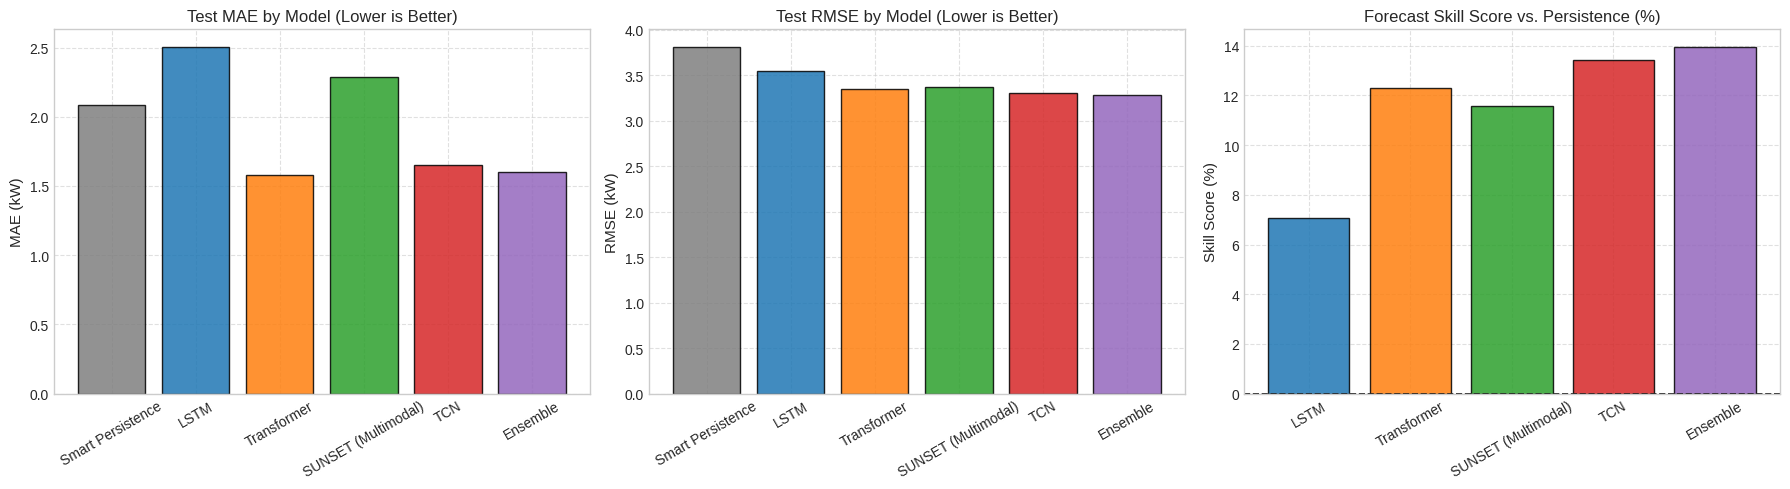

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MAE Comparison
models = list(df_results.index)
colors = ["#7f7f7f", "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

axes[0].bar(models, df_results["MAE (kW)"], color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Test MAE by Model (Lower is Better)")
axes[0].set_ylabel("MAE (kW)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. RMSE Comparison
axes[1].bar(
    models, df_results["RMSE (kW)"], color=colors, edgecolor="black", alpha=0.85
)
axes[1].set_title("Test RMSE by Model (Lower is Better)")
axes[1].set_ylabel("RMSE (kW)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, linestyle="--", alpha=0.6)

# 3. Forecast Skill Score
axes[2].bar(
    models[1:],
    df_results.loc[models[1:], "Skill Score (%)"],
    color=colors[1:],
    edgecolor="black",
    alpha=0.85,
)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[2].set_title("Forecast Skill Score vs. Persistence (%)")
axes[2].set_ylabel("Skill Score (%)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

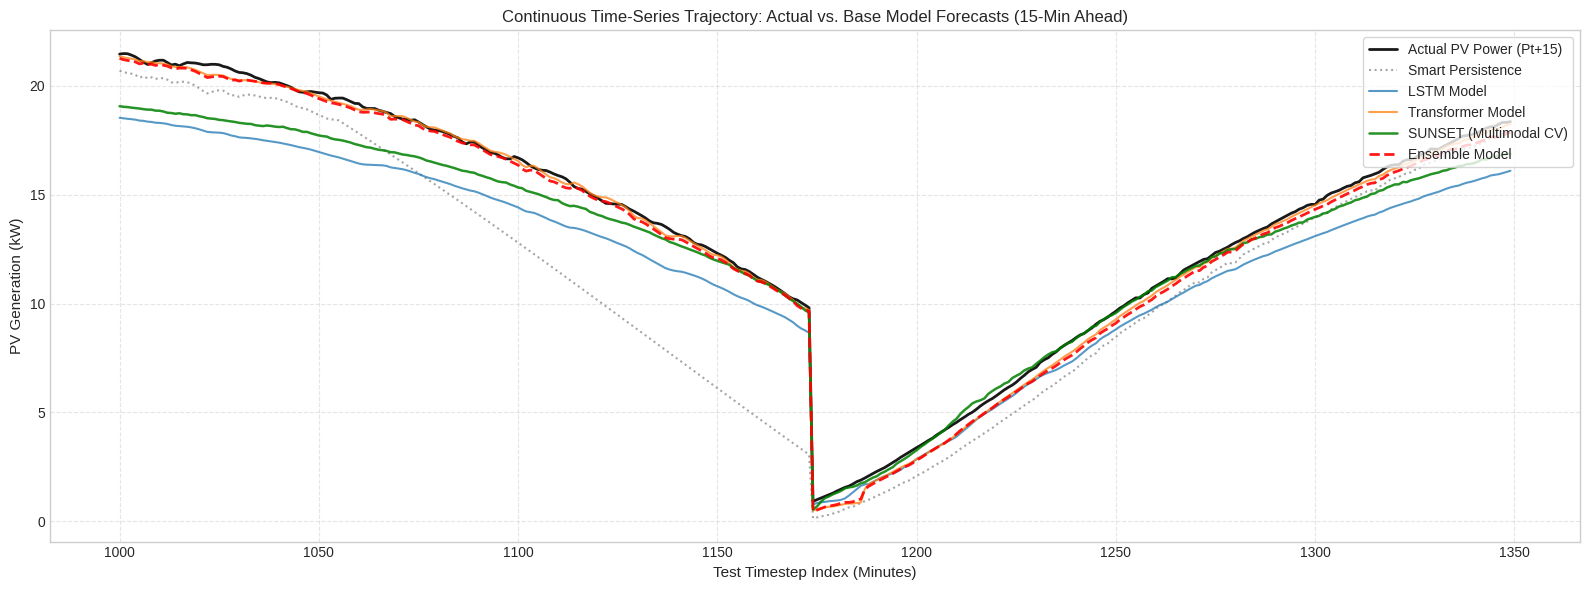

In [22]:
# Continuous Day Forecasting Profiles (Zoom on a 300-minute sample sequence)
sample_len = 350
start_idx = 1000
t_slice = np.arange(start_idx, start_idx + sample_len)

plt.figure(figsize=(16, 6))
plt.plot(
    t_slice,
    test_targets[t_slice],
    "k-",
    linewidth=2.0,
    label="Actual PV Power (Pt+15)",
    alpha=0.9,
)
plt.plot(
    t_slice,
    test_preds_persistence[t_slice],
    "gray",
    linestyle=":",
    label="Smart Persistence",
    alpha=0.7,
)
plt.plot(t_slice, test_preds_lstm[t_slice], label="LSTM Model", alpha=0.75)
plt.plot(t_slice, test_preds_trans[t_slice], label="Transformer Model", alpha=0.75)
plt.plot(
    t_slice,
    test_preds_sunset[t_slice],
    "g-",
    linewidth=1.8,
    label="SUNSET (Multimodal CV)",
    alpha=0.85,
)
plt.plot(
    t_slice,
    test_preds_ensemble[t_slice],
    "r--",
    linewidth=2.0,
    label="Ensemble Model",
    alpha=0.9,
)

plt.title(
    "Continuous Time-Series Trajectory: Actual vs. Base Model Forecasts (15-Min Ahead)"
)
plt.xlabel("Test Timestep Index (Minutes)")
plt.ylabel("PV Generation (kW)")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 10. DRL State & Feature Serialization Bridge (For `04-drl-agent.ipynb`)

To prepare the environment for the **Deep Reinforcement Learning (DRL) Adaptive Controller** in the next stage, we extract and serialize:

1. **Multimodal Feature Embeddings ($F_t$):** Latent multimodal representation from the SUNSET multimodal encoder ($F_{\text{multimodal}} \in \mathbb{R}^{64}$).
2. **Base Forecasts Vector ($\hat{P}_t$):** Array of base model forecasts $\hat{P}_t = [\hat{P}_{\text{LSTM}}, \hat{P}_{\text{Transformer}}, \hat{P}_{\text{SUNSET}}, \hat{P}_{\text{TCN}}] \in \mathbb{R}^4$.
3. **Physical State Variables:** Clear-sky generation $P_{\text{clear}}$, clear-sky index $k_t$, ramp indicator $R_t$, and categorical sky state $C_t$.
4. **Lagged Errors ($e_{t-1}$):** Previous timestep prediction error to allow the DRL agent to perform adaptive closed-loop correction.


In [23]:
import os
import shutil

# 1. Define export directories (Local + Google Drive)
local_export_dir = "/content/data/" if os.path.exists("/content") else "./data/"
os.makedirs(local_export_dir, exist_ok=True)
export_fname = "base_models_features_and_predictions.pt"
local_save_path = os.path.join(local_export_dir, export_fname)

drive_export_dir = "/content/drive/MyDrive/solar_data/"

print("Packaging state features and base model predictions for DRL Agent...")

# Compute 1-step lagged error for each model: e_{t-1} = P_{t-1} - \hat{P}_{t-1}
lagged_errors = np.zeros_like(test_preds_matrix)
lagged_errors[1:] = test_targets[:-1, None] - test_preds_matrix[:-1]

drl_state_payload = {
    # Multimodal feature embeddings F_t
    "multimodal_features": torch.from_numpy(test_lat_sunset).float(),
    "lstm_features": torch.from_numpy(test_lat_lstm).float(),
    "transformer_features": torch.from_numpy(test_lat_trans).float(),
    "tcn_features": torch.from_numpy(test_lat_tcn).float(),
    # Base model predictions matrix (N, 4): [LSTM, Transformer, SUNSET, TCN]
    "base_predictions": torch.from_numpy(test_preds_matrix).float(),
    "ensemble_predictions": torch.from_numpy(test_preds_ensemble).float(),
    "persistence_predictions": torch.from_numpy(test_preds_persistence).float(),
    # Ground truth actual generation P_t+H
    "actual_pv": torch.from_numpy(test_targets).float(),
    # Physics state metadata
    "p_clear": torch.from_numpy(test_pclear_target).float(),
    "k_t": torch.from_numpy(test_kt_current).float(),
    "ramp_rate": torch.from_numpy(df_te.loc[test_indices, "ramp_rate"].values).float(),
    "sky_condition": torch.from_numpy(test_sky_conditions).long(),
    "lagged_errors": torch.from_numpy(lagged_errors).float(),
    # Metadata config
    "models_order": ["LSTM", "Transformer", "SUNSET", "TCN"],
    "optimal_ensemble_weights": torch.from_numpy(optimal_weights).float(),
    "pv_capacity_kw": PV_SYSTEM_CAPACITY_KW,
    "lookback_window": LOOKBACK_WINDOW,
    "forecast_horizon": FORECAST_HORIZON,
}

# 2. Save locally first (fastest)
torch.save(drl_state_payload, local_save_path)
print(f"\n[1/2] Saved locally to: {local_save_path}")

# 3. Mount Google Drive and save permanently if running in Colab
try:
    if not os.path.exists("/content/drive/MyDrive"):
        from google.colab import drive

        drive.mount("/content/drive")
    os.makedirs(drive_export_dir, exist_ok=True)
    drive_save_path = os.path.join(drive_export_dir, export_fname)
    shutil.copyfile(local_save_path, drive_save_path)
    print(f"[2/2] Successfully backed up to Google Drive: {drive_save_path}")
except Exception as e:
    print(
        f"Note: Google Drive backup skipped or not in Colab ({e}). Artifact remains at: {local_save_path}"
    )

print("\nPayload Tensor Shapes:")
print(f"  Multimodal Features (F_t): {drl_state_payload['multimodal_features'].shape}")
print(f"  Base Predictions Matrix:   {drl_state_payload['base_predictions'].shape}")
print(f"  Actual Targets:            {drl_state_payload['actual_pv'].shape}")
print("=" * 70)
print("Base modeling phase complete! Ready for Notebook 04: DRL Adaptive Controller.")
print("=" * 70)

Packaging state features and base model predictions for DRL Agent...

[1/2] Saved locally to: /content/data/base_models_features_and_predictions.pt
[2/2] Successfully backed up to Google Drive: /content/drive/MyDrive/solar_data/base_models_features_and_predictions.pt

Payload Tensor Shapes:
  Multimodal Features (F_t): torch.Size([12657, 64])
  Base Predictions Matrix:   torch.Size([12657, 4])
  Actual Targets:            torch.Size([12657])
Base modeling phase complete! Ready for Notebook 04: DRL Adaptive Controller.
